In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [3]:
data = fetch_california_housing()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [4]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

In [6]:
model = DecisionTreeRegressor(max_depth=60, random_state=42)

model.fit(X_train,y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)



In [7]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f'train mse : {train_mse}')
print(f'test mse : {test_mse}')

train mse : 9.904697258622977e-32
test mse : 0.5265256772490148


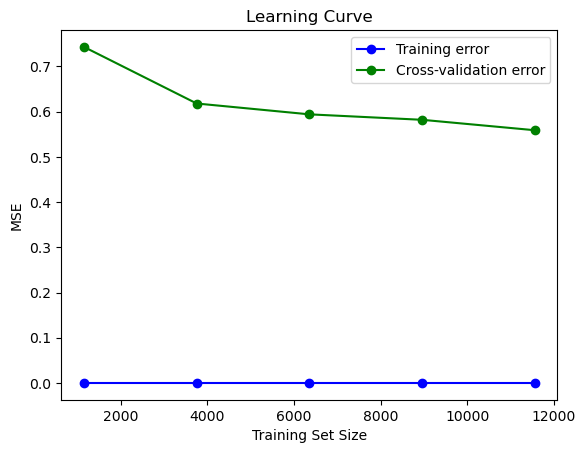

In [8]:
#PR
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [13]:
crossing = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

for i,scoring in enumerate(crossing):
    print(f'hasil scoring ke {i} : {abs(scoring)}')

hasil scoring ke 0 : 0.5785129996788927
hasil scoring ke 1 : 0.6105625788207958
hasil scoring ke 2 : 0.5164146290981315
hasil scoring ke 3 : 0.5315821084219106
hasil scoring ke 4 : 0.5442735132818622


In [ ]:
model_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
model_reg.fit(X_train,y_train)

y_train_reg_pred = model_reg.predict(X_train)